In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from tqdm import tqdm
from pathlib import Path

In [2]:
YEAR = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{YEAR}')

# Load data

In [3]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet").reset_index(drop=True)
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet").reset_index(drop=True)

print(f"# rows: {len(raw_Xy)}")
raw_Xy.head(1)

# rows: 944808


,red,green,blue,rededge,B06,B07,nir,B8A,swir11,swir22,...,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var,y,region,scl
0,0.145098,0.105882,0.07451,0.188235,0.203922,0.215686,0.215686,0.227451,0.309804,0.254902,...,0.00112,0.001609,0.000002,0.00679,0.006232,0.007676,0.000012,False,Upper East,NOT_VEGETATED


# Train:test:split

In [5]:
# Decide on which region to train for
REGION = 'Ashanti'
region_mask = raw_Xy.region == REGION

# Discard not-in-region data
raw_Xy = raw_Xy[region_mask]
metadata_df = metadata_df[region_mask]
print(f"Discarding out-of-region points: Kept {region_mask.sum()}/{len(region_mask)} ({region_mask.sum()/len(region_mask) * 100:.2f}%)")

# Figure out which folds are for train/val and which for test
test_size = 0.2
region_fold_idxs = metadata_df[region_mask].fold_idx.unique()
n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")

# Split
Xy_train = raw_Xy[~test_mask]
metadata_df_train = metadata_df[~test_mask]
Xy_test = raw_Xy[test_mask]
metadata_df_test = metadata_df[test_mask]

Discarding out-of-region points: Kept 99065/944808 (10.49%)
200/1000 regions for testing (19910 points)


/tmp/ipykernel_29065/2021917556.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  region_fold_idxs = metadata_df[region_mask].fold_idx.unique()


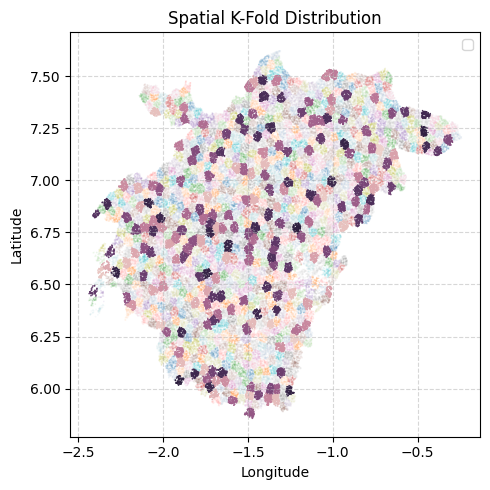

In [6]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=metadata_df[~test_mask], x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.1, edgecolor=None)
sns.scatterplot(data=metadata_df[test_mask], x='lon', y='lat', hue='fold_idx', color='r', s=1, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train models

In [7]:
# Build X,y
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Initialize and fit the Dummy Classifier
dummy_clf = DummyClassifier(strategy="stratified")
dummy_clf.fit(X_train, y_train > 0.65)
yhat_test = dummy_clf.predict(X_test)

# Evaluate the baseline
print(f"Baseline Macro F1: {f1_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Precision: {precision_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print(f"Baseline Macro Recall: {recall_score(y_test, yhat_test, average='macro', zero_division=0):.4f}")
print("- Negative (0)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=0, zero_division=0):.4f}")
print("- Positive (1)")
print(f"- F1: {f1_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Precision: {precision_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")
print(f"-- Recall: {recall_score(y_test, yhat_test, pos_label=1, zero_division=0):.4f}")

Baseline Macro F1: 0.5039
Baseline Macro Precision: 0.5040
Baseline Macro Recall: 0.5039
- Negative (0)
- F1: 0.7379
-- Precision: 0.7333
-- Recall: 0.7425
- Positive (1)
- F1: 0.2700
-- Precision: 0.2748
-- Recall: 0.2653


# Prep hyperparam optimization

In [8]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y, groups, n_splits: int = 100):
    # Safely determine max possible splits based on unique groups
    unique_groups = len(np.unique(groups))
    actual_splits = min(n_splits, unique_groups)
    
    if actual_splits < n_splits:
        print(f"Warning: Requested {n_splits} splits, but only found {unique_groups} unique groups. Adjusting n_splits to {actual_splits}.")

    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        gkf = GroupKFold(n_splits=actual_splits)
        
        # Initialize lists to store metrics and raw arrays
        true_f1s, true_precisions, true_recalls = [], [], []
        false_f1s, false_precisions, false_recalls = [], [], []
        all_yhat_vals, all_y_vals = [], []
        
        for train_idx, val_idx in gkf.split(X, y, groups):
            # Safe slicing regardless of whether X/y are pandas DataFrames/Series or numpy arrays
            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx] 
            
            # Fit/predict
            model = lgb.LGBMClassifier(**param)
            model.fit(X_train, y_train)
            yhat_val = model.predict(X_val)
            
            # Calculate and append metrics
            true_f1s.append(f1_score(y_val, yhat_val, zero_division=0))
            true_precisions.append(precision_score(y_val, yhat_val, zero_division=0))
            true_recalls.append(recall_score(y_val, yhat_val, zero_division=0))

            false_f1s.append(f1_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_precisions.append(precision_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_recalls.append(recall_score(y_val, yhat_val, zero_division=0, pos_label=0))
            
            all_yhat_vals.append(yhat_val.tolist())
            all_y_vals.append(y_val.tolist())

        # Store tracked data as user attributes in the trial
        trial.set_user_attr('true_f1s', true_f1s)
        trial.set_user_attr('true_precisions', true_precisions)
        trial.set_user_attr('true_recalls', true_recalls)
        trial.set_user_attr('false_f1s', false_f1s)
        trial.set_user_attr('false_precisions', false_precisions)
        trial.set_user_attr('false_recalls', false_recalls)
        trial.set_user_attr('yhat_vals', all_yhat_vals)
        trial.set_user_attr('y_vals', all_y_vals)
        
        return np.median(true_f1s)

    return objective

# Train dummy LGBM baseline

In [9]:
def get_dummy_feature(X):
    features = ["valid_observations"]
    return X[features]
    
# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_dummy_feature(X_train)
X_test = get_dummy_feature(X_test)

X_train.head(1)

,valid_observations
533004,7


In [10]:
def compute_a(y):
    return y.sum() / len(y)

a = compute_a(y_test)
print(f"{REGION}'s test cocoa area proportion (CAP): {a*100:.2f}%")

def compute_ahat(yhat, y_vals, yhat_vals):
    area_proportion_1 = yhat.sum() / len(yhat)
    area_proportion_0 = 1 - area_proportion_1
    
    # Figure out precision/false-omission-rate as the weighted-mean
    cms = [confusion_matrix(y_val, yhat_val, labels=[True, False]) for y_val, yhat_val in zip(y_vals, yhat_vals)] # (tp, fn), (fp, tn)
    tps = [e[0][0] for e in cms]
    fns = [e[0][1] for e in cms]
    tns = [e[1][1] for e in cms]
    fps = [e[1][0] for e in cms]

    # Figure out weighted-averaged TN, ...
    n_vals = np.array([len(e) for e in y_vals])
    tp = np.mean(tps)
    fn = np.mean(fns)
    fp = np.mean(fps)
    tn = np.mean(tns)

    # Compute validation set's metrics
    false_omission_rate = fn / (fn + tn)
    precision = tp / (tp + fp)

    # Compute adjusted unbiased area proportion
    ahat = (area_proportion_1 * precision) + (area_proportion_0 * false_omission_rate)

    # Compute Confidence Interval (Olofsson Variance)
    n_cocoa = tp + fp
    n_non_cocoa = fn + tn

    # Variance contribution from both strata
    var_cocoa = (area_proportion_1 ** 2) * (precision * (1 - precision)) / (n_cocoa - 1)
    var_non_cocoa = (area_proportion_0 ** 2) * (false_omission_rate * (1 - false_omission_rate)) / (n_non_cocoa - 1)
    
    # Standard Error
    se = np.sqrt(var_cocoa + var_non_cocoa)
    
    # Margin of Error for 95% Confidence Interval (Z-score = 1.96)
    margin_of_error = 1.96 * se
    
    ci_lower = max(0.0, ahat - margin_of_error) # Clamp at 0%
    ci_upper = min(1.0, ahat + margin_of_error) # Clamp at 100%

    return ahat, (ci_lower, ci_upper)

Ashanti's test cocoa area proportion (CAP): 26.88%


In [11]:
def train_test_lgbm(X_train, y_train, X_test, y_test, groups, n_splits=100, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, n_splits), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)

    # Validation-inferred correction
    yhat_vals = [np.array(e) for e in study.best_trial.user_attrs['yhat_vals']]
    y_vals = [np.array(e) for e in study.best_trial.user_attrs['y_vals']]
    ahat, (ci_lower, ci_upper) = compute_ahat(yhat_test, y_vals, yhat_vals)
    a = compute_a(y_test)
    print(f"{REGION}'s test estimated CAP: {ahat*100:.2f}% ({100 * ahat / a - 100:.2f}% off ETHZ's estimate) [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- F1: {f1_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_train, yhat_train, zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- F1: {f1_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_test, yhat_test, zero_division=0):.4f}")

    return clf, study.best_trial.user_attrs

train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=2, n_trials=1);

[I 2026-06-25 15:16:30,825] A new study created in memory with name: no-name-d06765e1-b1ee-4f69-a78f-6035aed78ea2


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-25 15:16:31,738] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 392, 'learning_rate': 0.020387160938738984, 'max_depth': 12, 'num_leaves': 110, 'subsample': 0.9528242143745496, 'colsample_bytree': 0.9196312170221104, 'min_child_samples': 95}. Best is trial 0 with value: 0.0.
Ashanti's test estimated CAP: 25.83% (-3.91% off ETHZ's estimate) [25.40%, 26.26%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.0009
- Precision: 0.6000
- Recall: 0.0004

TEST
- F1: 0.0000
- Precision: 0.0000
- Recall: 0.0000


# Train LGBM baseline

In [12]:
# Baseline LGBM
from sklearn.preprocessing import StandardScaler

def get_base_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_features(X_train)
X_test = get_base_features(X_test)

# 4. Fit AND transform on 2021 (Train)
scaler_train = StandardScaler()
X_train = pd.DataFrame(scaler_train.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

scaler_test = StandardScaler()
X_test = pd.DataFrame(scaler_test.fit_transform(X_test), columns=X_test.columns, index=X_test.index)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22
533004,1.358112,1.624071,1.954314,1.678363,-0.058715,-0.378285,-0.238491,-0.263025,2.341971,2.539261


In [13]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=5, n_trials=1);

[I 2026-06-25 15:16:38,257] A new study created in memory with name: no-name-55df1360-27b4-40ce-8e87-97f96c1bdd0c


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-25 15:16:42,222] Trial 0 finished with value: 0.6773070922836913 and parameters: {'n_estimators': 494, 'learning_rate': 0.03441928899514943, 'max_depth': 5, 'num_leaves': 226, 'subsample': 0.9200368476474307, 'colsample_bytree': 0.8565068446429187, 'min_child_samples': 32}. Best is trial 0 with value: 0.6773070922836913.
Ashanti's test estimated CAP: 26.76% (-0.46% off ETHZ's estimate) [26.18%, 27.33%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.7007
- Precision: 0.7011
- Recall: 0.7002

TEST
- F1: 0.6920
- Precision: 0.6844
- Recall: 0.6997


# Consider the SCL

In [14]:
# Take into account this SCL
def get_base_and_scl_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_features(X_train)
X_test = get_base_and_scl_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,scl
533004,0.043137,0.062745,0.070588,0.145098,0.133333,0.145098,0.12549,0.145098,0.211765,0.176471,NOT_VEGETATED


In [15]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=10, n_trials=1)

[I 2026-06-25 15:16:53,916] A new study created in memory with name: no-name-980f1303-c65e-4c34-b2c9-d327e71b2fee


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-25 15:17:06,218] Trial 0 finished with value: 0.6668973161337264 and parameters: {'n_estimators': 477, 'learning_rate': 0.0230537066267086, 'max_depth': 15, 'num_leaves': 26, 'subsample': 0.5213908285206377, 'colsample_bytree': 0.8468819625828607, 'min_child_samples': 47}. Best is trial 0 with value: 0.6668973161337264.
Ashanti's test estimated CAP: 26.68% (-0.74% off ETHZ's estimate) [25.87%, 27.49%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.6972
- Precision: 0.7013
- Recall: 0.6931

TEST
- F1: 0.6891
- Precision: 0.6886
- Recall: 0.6896


# Add TCI & other features

In [16]:
# Take into account this SCL
def get_base_and_scl_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_advanced_features(X_train)
X_test = get_base_and_scl_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,scl,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi
533004,0.043137,0.062745,0.070588,0.145098,0.133333,0.145098,0.12549,0.145098,0.211765,0.176471,NOT_VEGETATED,0.081956,0.001098,0.000614,0.001801,0.0,0.000166,0.0,0.001307,0.01067


In [17]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=20, n_trials=1)

[I 2026-06-25 15:17:11,747] A new study created in memory with name: no-name-98aec5ac-1f9d-45fc-be0f-1feaa2ce918c


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-25 15:17:49,403] Trial 0 finished with value: 0.6783539456959919 and parameters: {'n_estimators': 394, 'learning_rate': 0.013376269408089796, 'max_depth': 6, 'num_leaves': 77, 'subsample': 0.9987678632158887, 'colsample_bytree': 0.5125630013639935, 'min_child_samples': 84}. Best is trial 0 with value: 0.6783539456959919.
Ashanti's test estimated CAP: 26.84% (-0.14% off ETHZ's estimate) [25.70%, 27.99%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.6887
- Precision: 0.6886
- Recall: 0.6889

TEST
- F1: 0.6886
- Precision: 0.6812
- Recall: 0.6962


# Keep track of #valid observations

In [18]:
# Take into account this SCL
def get_base_and_scl_and_obs_cnt_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_advanced_features(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations
533004,0.043137,0.062745,0.070588,0.145098,0.133333,0.145098,0.12549,0.145098,0.211765,0.176471,...,0.081956,0.001098,0.000614,0.001801,0.0,0.000166,0.0,0.001307,0.01067,7


In [19]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=20, n_trials=1)

[I 2026-06-25 15:18:00,134] A new study created in memory with name: no-name-2b3bf8cf-65d7-43f6-b656-4d35232ad724


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-25 15:18:18,365] Trial 0 finished with value: 0.6990239946990704 and parameters: {'n_estimators': 306, 'learning_rate': 0.07163556999740614, 'max_depth': 5, 'num_leaves': 186, 'subsample': 0.8716503739694516, 'colsample_bytree': 0.8519259557118436, 'min_child_samples': 24}. Best is trial 0 with value: 0.6990239946990704.
Ashanti's test estimated CAP: 26.50% (-1.42% off ETHZ's estimate) [25.38%, 27.62%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.7304
- Precision: 0.7228
- Recall: 0.7383

TEST
- F1: 0.7064
- Precision: 0.6980
- Recall: 0.7151


# Keep track of cloud confidence

In [20]:
# Take into account cloud confidence
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndvi,evi,evi2,ndre_b5,ndre_b6,ndre_b7,gndvi,ndwi,valid_observations,cloud_confidence
533004,0.043137,0.062745,0.070588,0.145098,0.133333,0.145098,0.12549,0.145098,0.211765,0.176471,...,0.001098,0.000614,0.001801,0.0,0.000166,0.0,0.001307,0.01067,7,1


In [21]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=20, n_trials=1)

[I 2026-06-25 15:18:19,797] A new study created in memory with name: no-name-07929461-0df5-48df-bc89-d86d116f1421


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-25 15:18:43,964] Trial 0 finished with value: 0.7006133072759506 and parameters: {'n_estimators': 293, 'learning_rate': 0.09795098988702468, 'max_depth': 6, 'num_leaves': 236, 'subsample': 0.7772279416827172, 'colsample_bytree': 0.8852923234546304, 'min_child_samples': 87}. Best is trial 0 with value: 0.7006133072759506.
Ashanti's test estimated CAP: 26.36% (-1.93% off ETHZ's estimate) [25.25%, 27.47%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.7556
- Precision: 0.7465
- Recall: 0.7649

TEST
- F1: 0.7022
- Precision: 0.6974
- Recall: 0.7070


# Rely on neighbor pixels

In [22]:
# Take into account cloud confidence
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in X.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    return X[features]

# Get train:test
X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

# Get features
X_train = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X_train)
X_test = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features_and_neighbor(X_test)

X_train.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,ndre_b7_11x11_max,ndre_b7_11x11_var,gndvi_11x11_median,gndvi_11x11_min,gndvi_11x11_max,gndvi_11x11_var,ndwi_11x11_median,ndwi_11x11_min,ndwi_11x11_max,ndwi_11x11_var
533004,0.043137,0.062745,0.070588,0.145098,0.133333,0.145098,0.12549,0.145098,0.211765,0.176471,...,0.023716,0.01473,0.001418,0.001008,0.001802,0.000006,0.011018,0.009679,0.020275,0.001227


In [23]:
clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, metadata_df_train.fold_idx, n_splits=3, n_trials=1)

[I 2026-06-25 15:18:45,736] A new study created in memory with name: no-name-1b337a5e-e3be-4bfb-b04f-d9dabd6ef62d


Starting Optuna hyperparameter optimization...


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-06-25 15:18:59,189] Trial 0 finished with value: 0.7895486935866983 and parameters: {'n_estimators': 151, 'learning_rate': 0.0523094690112946, 'max_depth': 9, 'num_leaves': 130, 'subsample': 0.6415077944697657, 'colsample_bytree': 0.5633492692613021, 'min_child_samples': 22}. Best is trial 0 with value: 0.7895486935866983.
Ashanti's test estimated CAP: 26.64% (-0.90% off ETHZ's estimate) [26.27%, 27.01%]

--- OPTIMIZED MODEL EVALUATION ---
TRAIN
- F1: 0.9031
- Precision: 0.8892
- Recall: 0.9175

TEST
- F1: 0.8048
- Precision: 0.8010
- Recall: 0.8087


# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?